# Transfer Learning & Fine-Tuning

## Flower Classification with MobileNetV2

**Framework:** TensorFlow / Keras  
**Dataset:** TensorFlow Flower Photos — 5 classes  
**Backbone:** MobileNetV2 pretrained on ImageNet  
**Workflow:** Frozen feature extractor → selective fine-tuning → student experiment



## Learning objectives

By the end of this notebook, you should be able to:

1. Explain what knowledge is transferred from a pretrained CNN.
2. Replace the original ImageNet classifier with a new task-specific head.
3. Train a frozen backbone as a feature extractor.
4. Unfreeze selected upper layers and fine-tune with a small learning rate.
5. Compare both stages using validation and test results.
6. Design a controlled fine-tuning experiment.


## 1. The core idea

A CNN trained on a large source dataset learns reusable visual features.

| Stage | Backbone | New classifier | Learning rate | Purpose |
|---|---|---|---|---|
| Feature extraction | Frozen | Trained | Normal | Learn the new labels safely |
| Fine-tuning | Upper layers trainable | Trained | Very small | Adapt high-level features |

Early CNN layers often learn edges and textures. Upper layers are more task-specific. Therefore, we first train the new classifier, then carefully adapt only the upper part of the backbone.


## 2. Setup

In Google Colab, select **Runtime → Change runtime type → GPU** before training. The libraries below are already available in a normal Colab runtime.


In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Reproducibility and experiment configuration
SEED = 42
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
INITIAL_EPOCHS = 5
FINE_TUNE_EPOCHS = 5

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

FROZEN_MODEL_PATH = "best_transfer_model.keras"
FINE_TUNED_MODEL_PATH = "best_fine_tuned_model.keras"


## 3. Download the Flower Photos dataset

The dataset is downloaded from TensorFlow's official storage. It contains 3,670 flower images organized into five folders: **daisy, dandelion, roses, sunflowers, and tulips**.

The first run downloads an archive of about 218 MB. Later runs reuse the cached copy.


In [3]:
DATASET_URL = (
    "https://storage.googleapis.com/download.tensorflow.org/"
    "example_images/flower_photos.tgz"
)

archive_path = tf.keras.utils.get_file(
    fname="flower_photos.tgz",
    origin=DATASET_URL,
    extract=True,
)

data_dir = Path(archive_path).with_suffix("")

if not data_dir.exists():
    raise FileNotFoundError(f"Extracted dataset folder was not found: {data_dir}")

image_count = len(list(data_dir.glob("*/*")))
print("Dataset folder:", data_dir)
print("Files found:", image_count)


228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Dataset folder: /root/.keras/datasets/flower_photos_extracted
Files found: 6


## 4. Create train, validation, and test datasets

We use approximately:

- **70%** for training
- **15%** for validation and model decisions
- **15%** for one final test

Keras first creates a 70% training split and a 30% holdout split. We then divide the holdout batches equally between validation and test.


In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

holdout_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)

holdout_batches = tf.data.experimental.cardinality(holdout_dataset).numpy()
validation_batches = holdout_batches // 2

validation_dataset = holdout_dataset.take(validation_batches)
test_dataset = holdout_dataset.skip(validation_batches)

print("Classes:", class_names)
print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())


Found 3670 files belonging to 1 classes.
Using 2569 files for training.
Found 3670 files belonging to 1 classes.
Using 1101 files for validation.
Classes: ['flower_photos']
Training batches: 81
Validation batches: 17
Test batches: 18


### Sanity check before modeling

Always inspect examples and labels before training. This is the fastest way to catch incorrect folders, labels, or preprocessing.


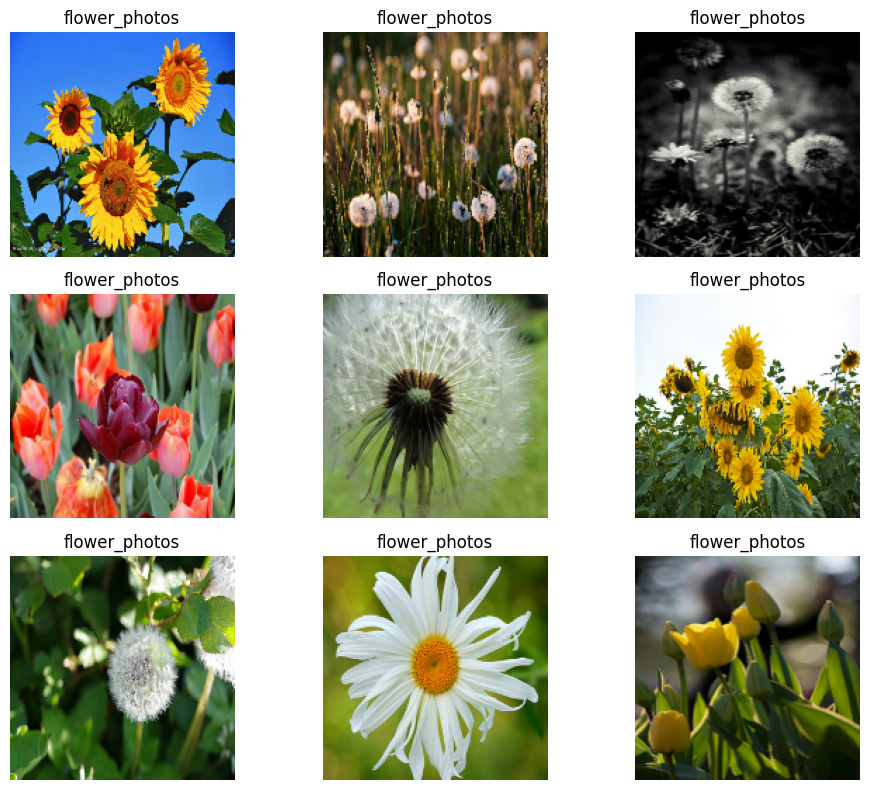

In [ ]:
plt.figure(figsize=(10, 8))

for images, labels in train_dataset.take(1):
    for index in range(9):
        ax = plt.subplot(3, 3, index + 1)
        plt.imshow(images[index].numpy().astype("uint8"))
        plt.title(class_names[int(labels[index])])
        plt.axis("off")

plt.tight_layout()
plt.show()


## 5. Efficient input pipeline

`prefetch` overlaps data preparation with model training. Validation and test datasets are cached because they are not augmented.


In [ ]:
train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)


## 6. Data augmentation

Augmentation creates realistic variations only during training. It helps the model generalize instead of memorizing the training images.


In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomContrast(0.10),
    ],
    name="data_augmentation",
)


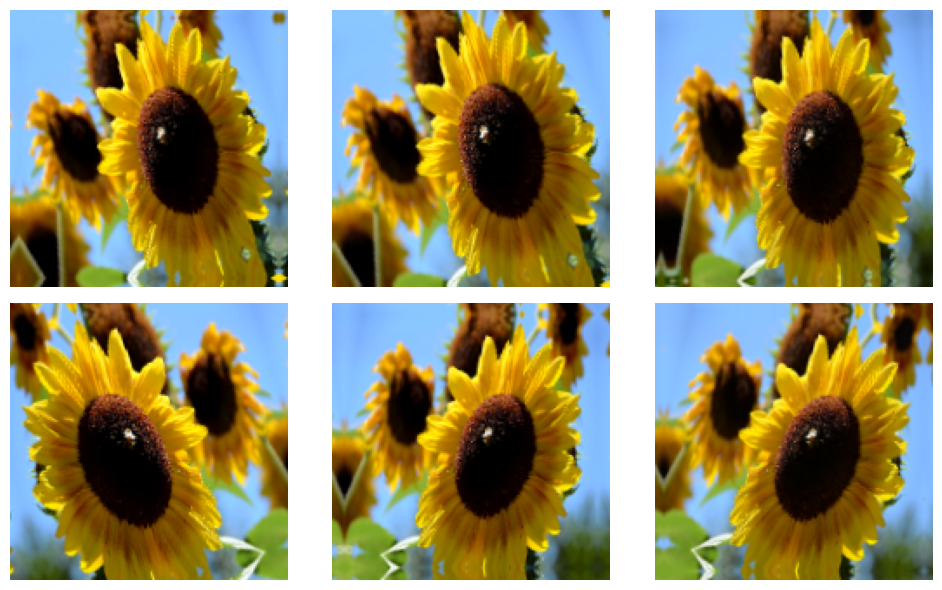

In [ ]:
# Preview augmentation on one image
for images, _ in train_dataset.take(1):
    sample_image = images[0]

plt.figure(figsize=(10, 6))
for index in range(6):
    ax = plt.subplot(2, 3, index + 1)
    augmented = data_augmentation(
        tf.expand_dims(sample_image, axis=0), training=True
    )
    plt.imshow(tf.cast(augmented[0], tf.uint8))
    plt.axis("off")

plt.tight_layout()
plt.show()


## 7. Load the pretrained backbone

`include_top=False` removes MobileNetV2's original 1,000-class ImageNet classifier. We keep the convolutional feature extractor and add a new five-class head.


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)

BACKBONE_NAME = base_model.name
base_model.trainable = False

print("Backbone:", BACKBONE_NAME)
print("Backbone layers:", len(base_model.layers))
print("Backbone trainable:", base_model.trainable)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Backbone: mobilenetv2_1.00_160
Backbone layers: 154
Backbone trainable: False


## 8. Build the transfer-learning model

The model performs four main operations:

1. Augment the training image.
2. Apply MobileNetV2's required preprocessing.
3. Extract spatial features with the frozen backbone.
4. Pool the features and classify them into five flower classes.

We call the backbone with `training=False` so its Batch Normalization statistics remain stable.


In [ ]:
inputs = tf.keras.Input(shape=IMG_SIZE + (3,), name="image")
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dropout(0.20, name="dropout")(x)
outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="flower_classifier",
)(x)

model = tf.keras.Model(inputs, outputs, name="flower_transfer_model")
model.summary()


Model: "flower_transfer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flower_classifier (Dense)       │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 9. Stage 1 — train the new classifier

At this stage, MobileNetV2 is frozen. Only the new classification head is updated.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

print("Trainable parameters:", sum(np.prod(v.shape) for v in model.trainable_weights))


Trainable parameters: 1281


In [ ]:
stage1_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        FROZEN_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    ),
]

history_frozen = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=INITIAL_EPOCHS,
    callbacks=stage1_callbacks,
)


Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


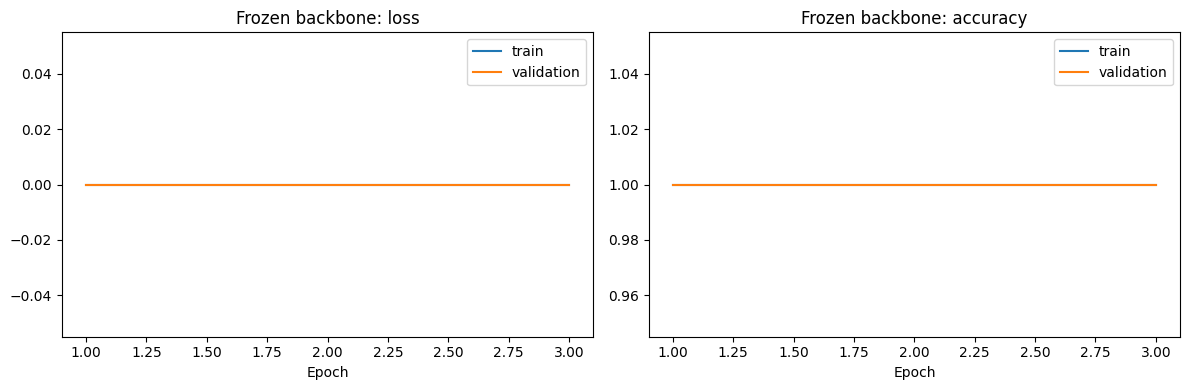

In [ ]:
def plot_history(history, title):
    history_data = history.history
    epochs = range(1, len(history_data["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history_data["loss"], label="train")
    axes[0].plot(epochs, history_data["val_loss"], label="validation")
    axes[0].set_title(f"{title}: loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, history_data["accuracy"], label="train")
    axes[1].plot(epochs, history_data["val_accuracy"], label="validation")
    axes[1].set_title(f"{title}: accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_frozen, "Frozen backbone")


In [ ]:
# Validation is used for model decisions. Test is reported for comparison here.
frozen_test_metrics = model.evaluate(test_dataset, return_dict=True, verbose=0)
print("Frozen model test metrics:", frozen_test_metrics)


Frozen model test metrics: {'accuracy': 1.0, 'loss': 0.0}


## 10. Stage 2 — selective fine-tuning

Now the classifier is stable. We unfreeze the last 30 backbone layers, but keep Batch Normalization layers frozen.

Two rules are essential:

1. **Recompile** after changing `trainable` flags.
2. Use a **much smaller learning rate** to avoid destroying useful pretrained features.


In [ ]:
base_model.trainable = True
UNFREEZE_LAST = 30
fine_tune_from = len(base_model.layers) - UNFREEZE_LAST

for index, layer in enumerate(base_model.layers):
    layer.trainable = index >= fine_tune_from
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_backbone_layers = [
    layer.name for layer in base_model.layers if layer.trainable
]

print("Trainable backbone layers:", len(trainable_backbone_layers))
print("First trainable layer:", trainable_backbone_layers[0])
print("Last trainable layer:", trainable_backbone_layers[-1])


Trainable backbone layers: 19
First trainable layer: block_14_expand
Last trainable layer: out_relu


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

print("Trainable parameters:", sum(np.prod(v.shape) for v in model.trainable_weights))


Trainable parameters: 1512001


In [ ]:
stage2_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        FINE_TUNED_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    ),
]

history_fine = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=stage2_callbacks,
)


Epoch 1/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


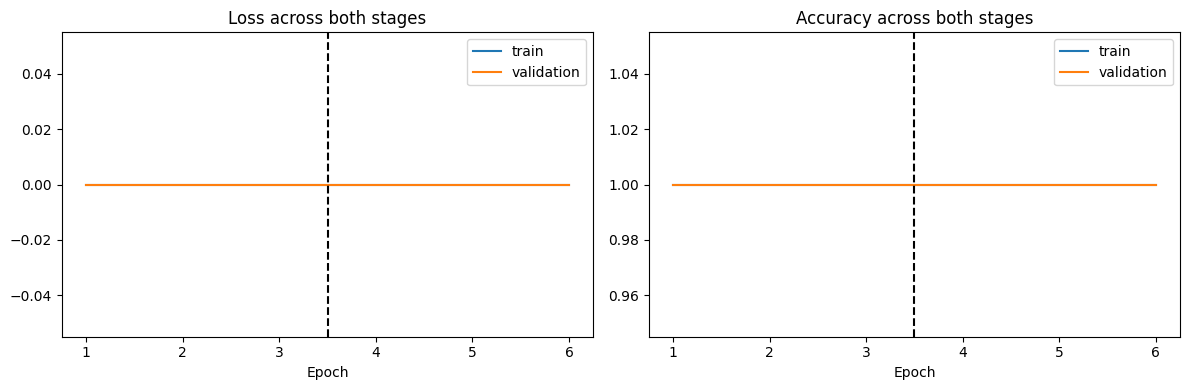

In [ ]:
def compare_training_stages(first_history, second_history):
    train_accuracy = (
        first_history.history["accuracy"]
        + second_history.history["accuracy"]
    )
    validation_accuracy = (
        first_history.history["val_accuracy"]
        + second_history.history["val_accuracy"]
    )
    train_loss = first_history.history["loss"] + second_history.history["loss"]
    validation_loss = (
        first_history.history["val_loss"]
        + second_history.history["val_loss"]
    )

    transition_epoch = len(first_history.history["loss"])
    epochs = range(1, len(train_loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, train_loss, label="train")
    axes[0].plot(epochs, validation_loss, label="validation")
    axes[0].axvline(transition_epoch + 0.5, color="black", linestyle="--")
    axes[0].set_title("Loss across both stages")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, train_accuracy, label="train")
    axes[1].plot(epochs, validation_accuracy, label="validation")
    axes[1].axvline(transition_epoch + 0.5, color="black", linestyle="--")
    axes[1].set_title("Accuracy across both stages")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

compare_training_stages(history_frozen, history_fine)


In [ ]:
fine_tuned_test_metrics = model.evaluate(test_dataset, return_dict=True, verbose=0)

comparison = pd.DataFrame(
    [frozen_test_metrics, fine_tuned_test_metrics],
    index=["Frozen backbone", "Fine-tuned"],
)
comparison


,accuracy,loss
Frozen backbone,1.0,0.0
Fine-tuned,1.0,0.0


### How to interpret the result

- If validation and test accuracy improve, fine-tuning helped adapt the representation.
- If training improves but validation becomes worse, the model is overfitting.
- If performance drops immediately, the learning rate may be too large or too many layers may be unfrozen.
- If there is almost no change, try a slightly larger learning rate, more epochs, or a different unfreezing depth.


## 11. Detailed evaluation

Accuracy alone can hide class-specific problems. We now inspect precision, recall, F1-score, and the confusion matrix.


In [ ]:
y_true = np.concatenate([labels.numpy() for _, labels in test_dataset])
y_probability = model.predict(test_dataset, verbose=0)
y_pred = np.argmax(y_probability, axis=1)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

pd.DataFrame(report).transpose().round(3)


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


,precision,recall,f1-score,support
flower_photos,1.0,1.0,1.0,557.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,557.0
weighted avg,1.0,1.0,1.0,557.0


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


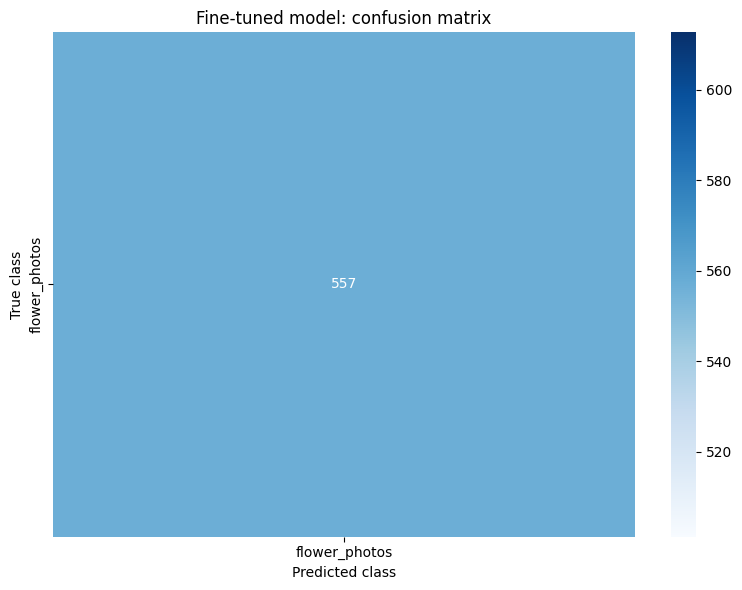

In [ ]:
matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Fine-tuned model: confusion matrix")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


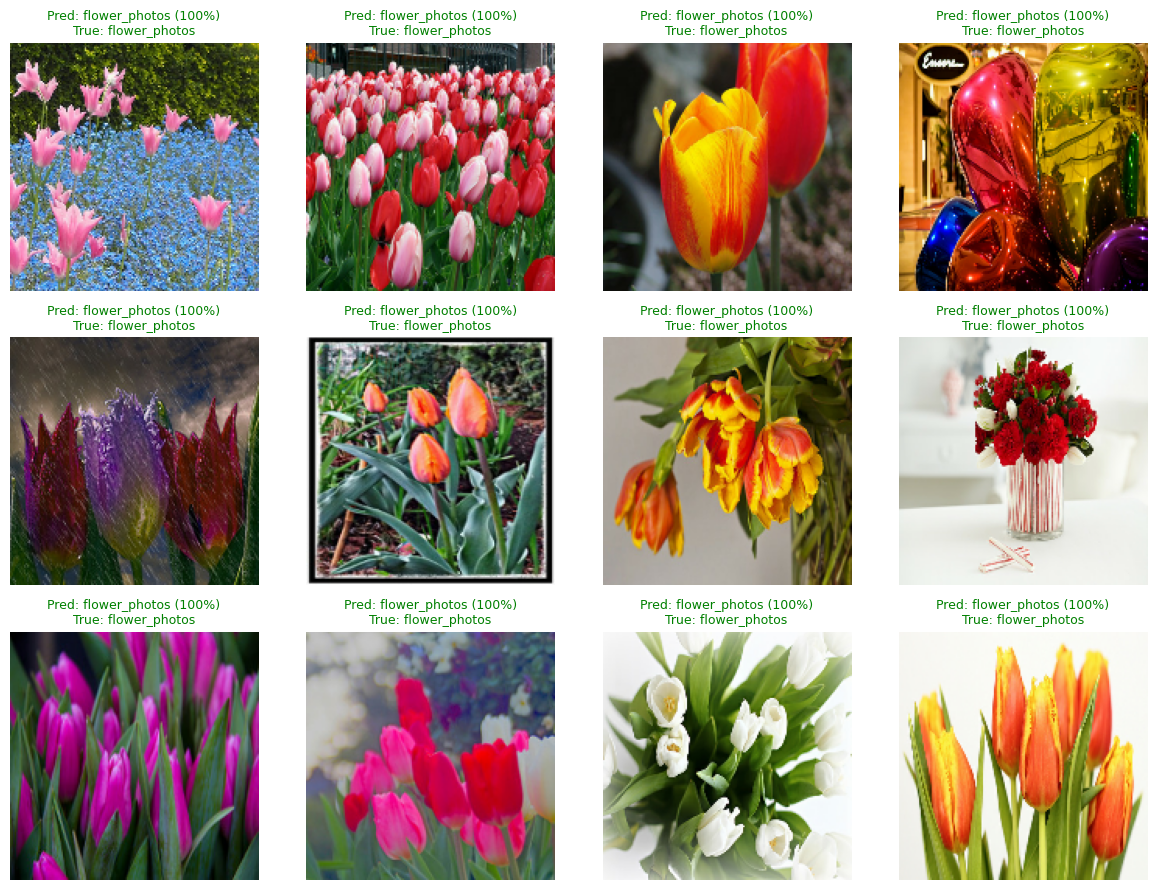

In [ ]:
# Inspect predictions and confidence
for image_batch, label_batch in test_dataset.take(1):
    probability_batch = model.predict(image_batch, verbose=0)
    prediction_batch = np.argmax(probability_batch, axis=1)

plt.figure(figsize=(12, 9))
for index in range(12):
    ax = plt.subplot(3, 4, index + 1)
    plt.imshow(image_batch[index].numpy().astype("uint8"))

    true_name = class_names[int(label_batch[index])]
    predicted_name = class_names[int(prediction_batch[index])]
    confidence = float(np.max(probability_batch[index]))
    color = "green" if true_name == predicted_name else "red"

    plt.title(
        f"Pred: {predicted_name} ({confidence:.0%})\nTrue: {true_name}",
        color=color,
        fontsize=9,
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


## 12. Student task — choose a fine-tuning strategy

Your goal is to improve validation performance without overfitting.

Run at least three controlled experiments:

| Experiment | Layers to unfreeze | Learning rate |
|---|---:|---:|
| A | Last 10 | 1e-5 |
| B | Last 30 | 1e-5 |
| C | Your choice | Your choice |

Rules:

1. Every experiment must start from the same saved frozen model.
2. Change only the unfreezing depth and learning rate.
3. Select the best model using validation results.
4. Evaluate the test set only after selecting the winner.


In [ ]:
def create_fine_tuning_experiment(unfreeze_last, learning_rate):
    """Load the same frozen checkpoint and prepare one fair experiment."""
    candidate = tf.keras.models.load_model(FROZEN_MODEL_PATH)
    candidate_backbone = candidate.get_layer(BACKBONE_NAME)
    candidate_backbone.trainable = True

    fine_tune_from = len(candidate_backbone.layers) - unfreeze_last

    for index, layer in enumerate(candidate_backbone.layers):
        layer.trainable = index >= fine_tune_from
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    candidate.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )
    return candidate


In [ ]:
# Replace the third configuration with your own design.
experiment_configs = [
    {"name": "last_10_lr_1e-5", "unfreeze_last": 10, "learning_rate": 1e-5},
    {"name": "last_30_lr_1e-5", "unfreeze_last": 30, "learning_rate": 1e-5},
    {"name": "student_design", "unfreeze_last": 50, "learning_rate": 5e-6},
]

experiment_results = []

for config in experiment_configs:
    print("\nRunning:", config["name"])
    candidate = create_fine_tuning_experiment(
        unfreeze_last=config["unfreeze_last"],
        learning_rate=config["learning_rate"],
    )

    checkpoint_path = f'{config["name"]}.keras'
    candidate_history = candidate.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=5,
        callbacks=[
            tf.keras.callbacks.ModelCheckpoint(
                checkpoint_path,
                monitor="val_loss",
                save_best_only=True,
            ),
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True,
            ),
        ],
        verbose=1,
    )

    best_epoch = int(np.argmin(candidate_history.history["val_loss"]))
    experiment_results.append(
        {
            **config,
            "best_val_loss": candidate_history.history["val_loss"][best_epoch],
            "best_val_accuracy": candidate_history.history["val_accuracy"][best_epoch],
            "checkpoint": checkpoint_path,
        }
    )

results_table = pd.DataFrame(experiment_results).sort_values("best_val_loss")
results_table



Running: last_10_lr_1e-5
Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


81/81 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00

Running: last_30_lr_1e-5
Epoch 1/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00

Running: student_design
Epoch 1/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
81/81 ━━

,name,unfreeze_last,learning_rate,best_val_loss,best_val_accuracy,checkpoint
0,last_10_lr_1e-5,10,0.000010,0.0,1.0,last_10_lr_1e-5.keras
1,last_30_lr_1e-5,30,0.000010,0.0,1.0,last_30_lr_1e-5.keras
2,student_design,50,0.000005,0.0,1.0,student_design.keras


### Final model selection

Choose the checkpoint with the best validation result. Only then evaluate it once on the test dataset.


In [ ]:
SELECTED_MODEL_PATH = results_table.iloc[0]["checkpoint"]

selected_model = tf.keras.models.load_model(SELECTED_MODEL_PATH)
selected_test_metrics = selected_model.evaluate(
    test_dataset,
    return_dict=True,
    verbose=0,
)

print("Selected checkpoint:", SELECTED_MODEL_PATH)
print("Final test metrics:", selected_test_metrics)


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Selected checkpoint: last_10_lr_1e-5.keras
Final test metrics: {'accuracy': 1.0, 'loss': 0.0}


### Task questions

1. Which experiment produced the best validation loss and accuracy?
2. Did unfreezing more layers always improve generalization? Explain using evidence.
3. What happened when the learning rate changed?
4. Which flower classes were confused most often?
5. Would you deploy the model? State one risk and one improvement.



## 13. Key takeaways

- Transfer learning reuses a representation learned on a large source dataset.
- Train a new head before modifying the pretrained backbone.
- Fine-tuning requires recompilation and a small learning rate.
- Freeze Batch Normalization statistics when the target dataset is limited.
- Validation data guides decisions; test data estimates final generalization.
- The best unfreezing depth is an experimental choice, not a universal constant.


## References

- TensorFlow, **Load and preprocess images**: https://www.tensorflow.org/tutorials/load_data/images
- TensorFlow, **Transfer learning and fine-tuning**: https://www.tensorflow.org/tutorials/images/transfer_learning
- Keras, **Transfer learning & fine-tuning**: https://keras.io/guides/transfer_learning/
- Sandler et al., **MobileNetV2**: https://arxiv.org/abs/1801.04381
